In [ ]:
# =================================================================
# ANALISE DE DADOS ENEM - 2021 
# 
# Objetivo : 
# Analisar as médias das notas de Matemática e Redação por Estado e comparar o desempenho entre eles 
# 
# Etapas da Análise:
# 1. Importação dos Dados 
# 2. Seleção das colunas relevantes
# 3. Cálculo da média por estado 
# 4. Criação de Rankings
# 5. Comparaçã entre Matemática e Redação
# 6. Visualização dos resultados 
# ==================================================================  


# Importando bibliotecas para a manipulação e visualização dos dados:
import pandas as pd
from IPython.display import display
# caminho do arquivo de Microdados do ENEM: 
caminho = "MICRODADOS_ENEM_2021.csv"
# Selecionando apenas as colunas necessárias para a análise:
colunas = [
    "SG_UF_PROVA", # Estado onde a prova foi realizada
    "TP_SEXO",     # Sexo do participante
    "TP_ESCOLA",   # Tipo de Escola 
    "NU_NOTA_MT",  # Nota de Matemática
    "NU_NOTA_REDACAO" # Nota de Redação
]
# leitura do arquivo csv com os  Microdados do ENEM
# sep=";" pois o arquivo usa ponto e virgula como separador 
# enconding="latin-1" para permitir a leitura de caracteres especiais 
df = pd.read_csv(
    caminho,
    sep=";",
    encoding="latin-1",
    usecols=colunas
)

# excluir todos os valores vazios das tabelas Matemática e Redação:
df = df.dropna(subset=["NU_NOTA_MT", "NU_NOTA_REDACAO"])
# Apagar o indice do pandas 
df = df.reset_index(drop=True)


# amostrar apenas as 10 primeiras linhas da tabela :
display(df.head(10))
# amostrar informações da tabela :
display(df.info())
# contagem de linhas e colunas da tabela :
display(df.shape)


,TP_SEXO,TP_ESCOLA,SG_UF_PROVA,NU_NOTA_MT,NU_NOTA_REDACAO
0,M,1,AL,461.5,560.0
1,M,2,CE,659.5,780.0
2,F,2,CE,582.6,780.0
3,F,2,MG,493.4,520.0
4,F,2,BA,413.3,380.0
5,F,1,GO,796.7,980.0
6,F,2,RN,514.9,680.0
7,M,1,PA,509.7,560.0
8,F,1,MT,445.8,540.0
9,F,1,PE,553.1,720.0


<class 'pandas.DataFrame'>
RangeIndex: 2238107 entries, 0 to 2238106
Data columns (total 5 columns):
 #   Column           Dtype  
---  ------           -----  
 0   TP_SEXO          str    
 1   TP_ESCOLA        int64  
 2   SG_UF_PROVA      str    
 3   NU_NOTA_MT       float64
 4   NU_NOTA_REDACAO  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 85.4 MB


None

(2238107, 5)

POSIÇÃO,SG_UF_PROVA,NU_NOTA_REDACAO
1º,MG,656
2º,RJ,641
3º,SP,639
4º,ES,635
5º,SC,631
6º,DF,631
7º,SE,630
8º,RS,629
9º,RN,628
10º,GO,625


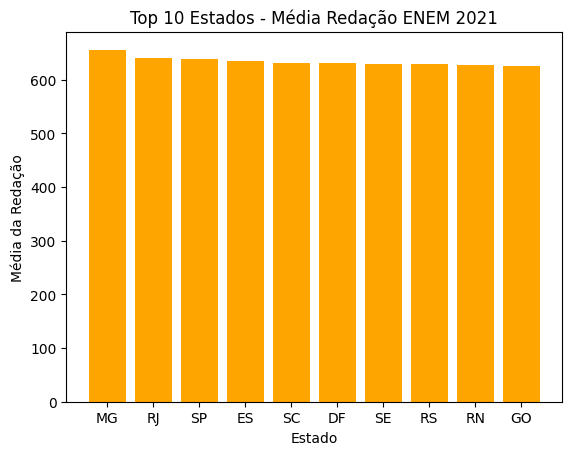

In [ ]:
# criando a media de redação por estado e ordenamos os estados pela maior média de redação :
media_ranking_redacao_estado = df.groupby("SG_UF_PROVA")["NU_NOTA_REDACAO"].mean().sort_values(ascending=False).reset_index()
# criamos a Posição no ranking :
media_ranking_redacao_estado["POSIÇÃO"] = range(1,len(media_ranking_redacao_estado)+1 )
# acrescentamos o sinal "º" no ranking :
media_ranking_redacao_estado["POSIÇÃO"] = media_ranking_redacao_estado["POSIÇÃO"].astype(str) + "º"
#0 CASAS DECIMAIS :
media_ranking_redacao_estado["NU_NOTA_REDACAO"] = (
    media_ranking_redacao_estado["NU_NOTA_REDACAO"].round(0).astype(int))
# Selecionamos as colunas que queremos que apareção na tabela: 
media_ranking_redacao_estado = media_ranking_redacao_estado[["POSIÇÃO" , "SG_UF_PROVA" , "NU_NOTA_REDACAO" ]]
# Amostramos as 10 primeiras linha , style = estilixação do pandas .hide(axis="index") pra esconder o indice do pandas :
display(media_ranking_redacao_estado.head(10).style.hide(axis="index"))
# importamos a biblioteca de graficos do pandas :
import matplotlib.pyplot as plt 

top10_redacao = media_ranking_redacao_estado.head(10)

plt.figure()
plt.bar(top10_redacao["SG_UF_PROVA"], top10_redacao["NU_NOTA_REDACAO"], color = 'orange') # definimos que a nota de redação sera de cor laranja no grafico
plt.title('Top 10 Estados - Média Redação ENEM 2021')# titulo do grafico 
plt.xlabel("Estado") # eixo x
plt.ylabel("Média da Redação") # eixo y 
plt.show()# amostrar o gráfico 



POSIÇÃO,SG_UF_PROVA,NU_NOTA_MT
1º,SP,568
2º,MG,562
3º,SC,557
4º,DF,552
5º,RS,551
6º,RJ,550
7º,ES,550
8º,PR,549
9º,RN,530
10º,MS,529


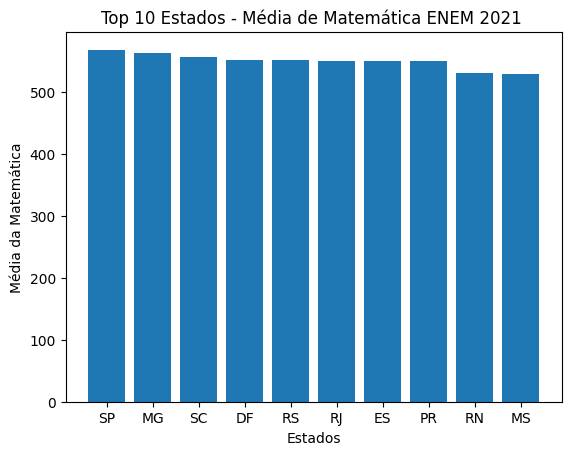

In [ ]:
# Média de matematica por estado  e ordenamos os estados pela maior nota de matematica 
media_ranking_matematica_estado = df.groupby("SG_UF_PROVA")["NU_NOTA_MT"].mean().sort_values(ascending=False).reset_index()

# CRIA A POSIÇÃO NUMERICA :
media_ranking_matematica_estado["POSIÇÃO"] = range(1, len(media_ranking_matematica_estado) + 1)
#CRIA O SINAL DE COLOCAÇÃO NO RANKING :
media_ranking_matematica_estado["POSIÇÃO"] = media_ranking_matematica_estado["POSIÇÃO"].astype(str) + "º"
#0 CASAS DECIMAIS :
media_ranking_matematica_estado["NU_NOTA_MT"] = (
    media_ranking_matematica_estado["NU_NOTA_MT"].round(0).astype(int)
)
# ORGANIZA AS COLUNAS QUE QUEREMOS :
media_ranking_matematica_estado = media_ranking_matematica_estado[["POSIÇÃO", "SG_UF_PROVA", "NU_NOTA_MT"]]

display(media_ranking_matematica_estado.head(10).style.hide(axis="index"))

import matplotlib.pyplot as plt

top10_matematica = media_ranking_matematica_estado.head(10)

plt.figure()
plt.bar(top10_matematica["SG_UF_PROVA"],top10_matematica["NU_NOTA_MT"])
plt.title("Top 10 Estados - Média de Matemática ENEM 2021 ")
plt.xlabel("Estados")
plt.ylabel("Média da Matemática")
plt.show()

In [ ]:
# unimos as duas analises (Matemática e redação) em uma unica tabela e utilizamos o estado como chave :
comparacao = media_ranking_matematica_estado.merge(
    media_ranking_redacao_estado,
    on="SG_UF_PROVA",
    suffixes=("_MT", "_RED")# evita conflitos de nomes de colunas 
)
# ordena os estados pela maior nota de matemática :
comparacao = comparacao.sort_values("NU_NOTA_MT", ascending=False)

# cria o ranking de matemática exemplo (1º,2º,3º):
comparacao["Rank Matemática"] = range(1, len(comparacao) + 1)

# adiciona o simbolo "º" e converte o ranking para texto :
comparacao["Rank Matemática"] = comparacao["Rank Matemática"].astype(str) + "º"

# orderna os estados pela maior média de redação :
comparacao = comparacao.sort_values("NU_NOTA_REDACAO", ascending=False)

# cria o ranking de Redação exemplo (1º,2º,3º):
comparacao["Rank Redação"] = range(1, len(comparacao) + 1)

# adiciona o simbolo "º" ao ranking  e converte para texto : 
comparacao["Rank Redação"] = comparacao["Rank Redação"].astype(str) + "º"

# Reordena novamente pela média de matematica para manter o ranking principal : 
comparacao = comparacao.sort_values("NU_NOTA_MT", ascending= False).reset_index()

# filtramos as colunas importantes para a visualização final :  
comparacao = comparacao[
      [
          "SG_UF_PROVA",
          "Rank Matemática",
          "NU_NOTA_MT",
          "Rank Redação",
          "NU_NOTA_REDACAO"
]
]
comparacao.head(10)


,SG_UF_PROVA,Rank Matemática,NU_NOTA_MT,Rank Redação,NU_NOTA_REDACAO
0,SP,1º,568,3º,639
1,MG,2º,562,1º,656
2,SC,3º,557,5º,631
3,DF,4º,552,6º,631
4,RS,5º,551,8º,629
5,RJ,6º,550,2º,641
6,ES,7º,550,4º,635
7,PR,8º,549,15º,614
8,RN,9º,530,9º,628
9,MS,10º,529,17º,605


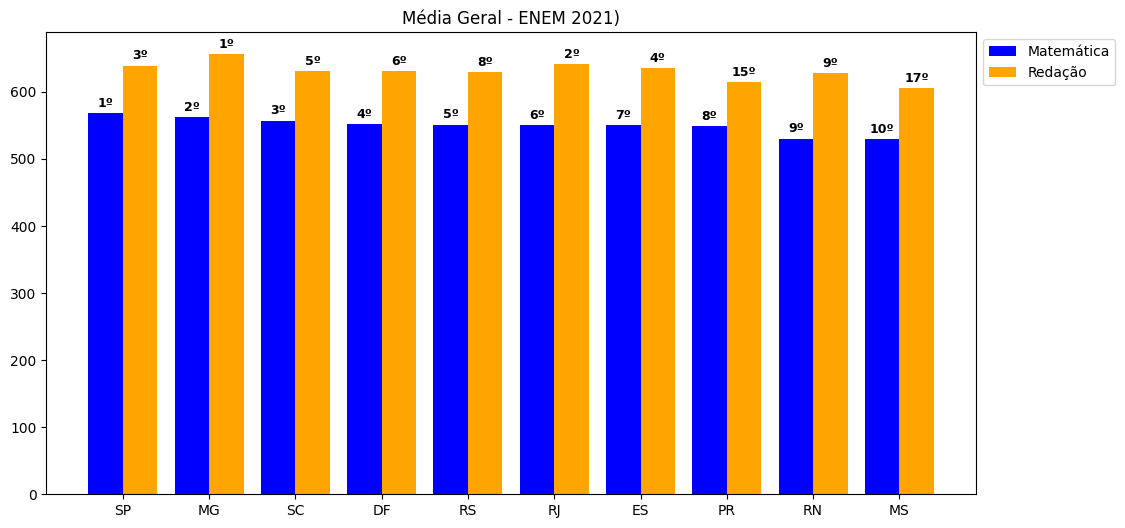

In [ ]:
                    
# criação dos graficos e manipulação númerica :
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparando os dados
top10 = comparacao.head(10)
x = np.arange(len(top10)) 
largura = 0.4

plt.figure(figsize=(12, 6))

# 2. Criando as barras (Guardamos em variáveis para saber a altura delas depois) de matematica e redação :
barras_mt = plt.bar(x - largura/2, top10["NU_NOTA_MT"], largura, label="Matemática", color="blue")
barras_red = plt.bar(x + largura/2, top10["NU_NOTA_REDACAO"], largura, label="Redação", color="orange")

# 3. FUNÇÃO SIMPLES PARA COLOCAR O RANK EM CIMA DA BARRA
def colocar_rank(barras, coluna_rank):
    for i, barra in enumerate(barras):
        #obtém a altura da barra (valor da nota):
        altura = barra.get_height()
        # obtem o rank correspondente daquela barra:
        rank = top10[coluna_rank].iloc[i]
        #escreve o ranking acima da barra : 
        plt.text(barra.get_x() + barra.get_width()/2, altura + 5, 
                 rank, ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chamando a função para as duas matérias
colocar_rank(barras_mt, "Rank Matemática")
colocar_rank(barras_red, "Rank Redação")

# 4. Ajustes finais
plt.xticks(x, top10["SG_UF_PROVA"])
plt.title("Média Geral - ENEM 2021)")
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1))

plt.show()

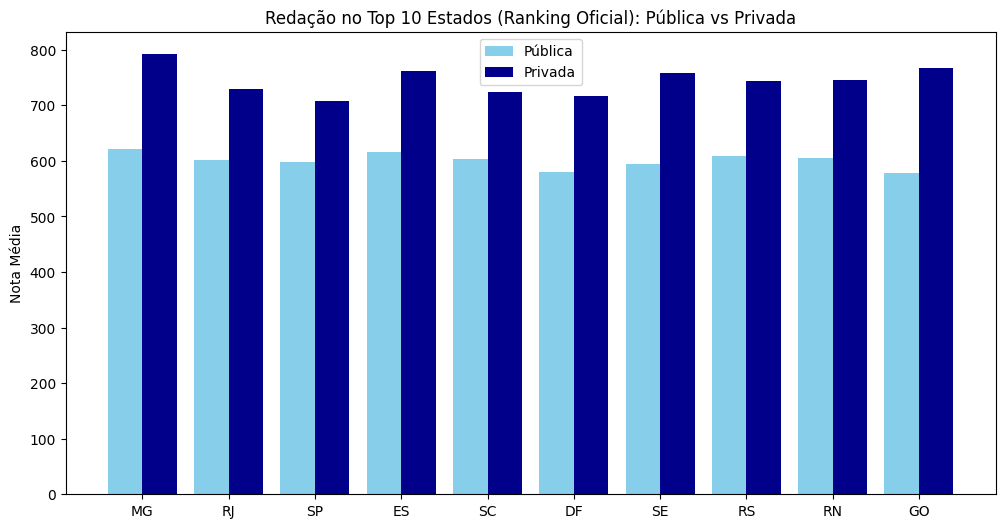

In [ ]:
# ESCOLA Públicas vs Privadas 
# --- PASSO 1: LIMPEZA ---
# Pegamos apenas quem declarou escola Pública (2) ou Privada (3)
df_escola = df[df['TP_ESCOLA'].isin([2, 3])].copy()

# --- PASSO 2: USAR SUA VARIÁVEL PRONTA ---
# Em vez de calcular, pegamos os 10 primeiros estados da sua variável de Redação
top10_ufs_redacao = media_ranking_redacao_estado.head(10)["SG_UF_PROVA"].tolist()

# --- PASSO 3: SEPARAR OS DADOS ---
# Filtramos as médias por escola, mas organizamos na ordem da SUA lista
escola_publica = df_escola[df_escola['TP_ESCOLA'] == 2].groupby("SG_UF_PROVA")["NU_NOTA_REDACAO"].mean().reindex(top10_ufs_redacao)
escola_privada = df_escola[df_escola['TP_ESCOLA'] == 3].groupby("SG_UF_PROVA")["NU_NOTA_REDACAO"].mean().reindex(top10_ufs_redacao)

# --- PASSO 4: GRÁFICO ---
import numpy as np
x = np.arange(len(top10_ufs_redacao)) 
largura = 0.4

plt.figure(figsize=(12, 6))
plt.bar(x - largura/2, escola_publica, largura, label="Pública", color="skyblue")
plt.bar(x + largura/2, escola_privada, largura, label="Privada", color="darkblue")

plt.xticks(x, top10_ufs_redacao)
plt.title("Redação no Top 10 Estados (Ranking Oficial): Pública vs Privada")
plt.ylabel("Nota Média")
plt.legend()
plt.show()

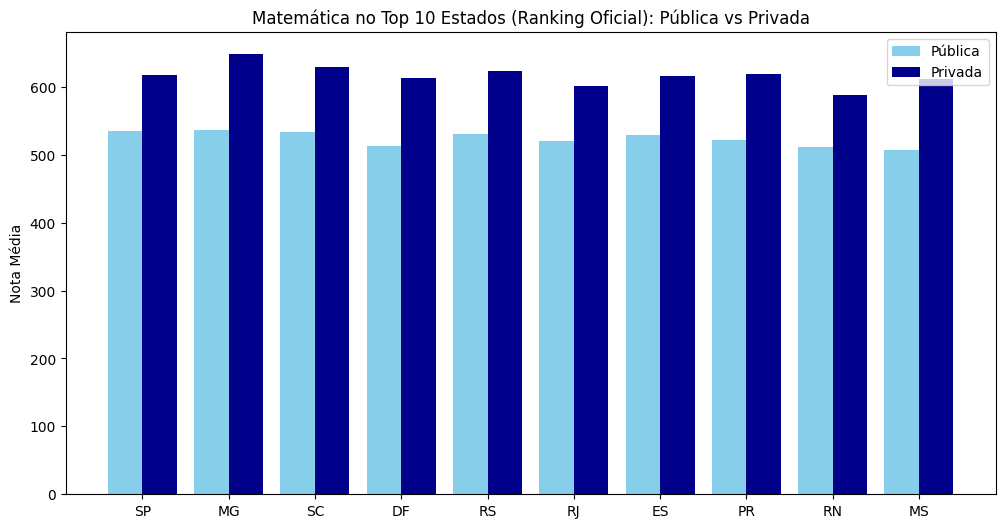

In [12]:
# --- PASSO 1: LIMPEZA ---
# Pegamos apenas quem declarou escola Pública (2) ou Privada (3)
df_escola = df[df['TP_ESCOLA'].isin([2, 3])].copy()

# --- PASSO 2: USAR SUA VARIÁVEL PRONTA ---
# Em vez de calcular, pegamos os 10 primeiros estados da sua variável de Redação
top10_ufs_matematica = media_ranking_matematica_estado.head(10)["SG_UF_PROVA"].tolist()

# --- PASSO 3: SEPARAR OS DADOS ---
# Filtramos as médias por escola, mas organizamos na ordem da SUA lista
escola_publica = df_escola[df_escola['TP_ESCOLA'] == 2].groupby("SG_UF_PROVA")["NU_NOTA_MT"].mean().reindex(top10_ufs_matematica)
escola_privada = df_escola[df_escola['TP_ESCOLA'] == 3].groupby("SG_UF_PROVA")["NU_NOTA_MT"].mean().reindex(top10_ufs_matematica)

# --- PASSO 4: GRÁFICO ---
import numpy as np
x = np.arange(len(top10_ufs_matematica)) 
largura = 0.4

plt.figure(figsize=(12, 6))
plt.bar(x - largura/2, escola_publica, largura, label="Pública", color="skyblue")
plt.bar(x + largura/2, escola_privada, largura, label="Privada", color="darkblue")

plt.xticks(x, top10_ufs_matematica)
plt.title("Matemática no Top 10 Estados (Ranking Oficial): Pública vs Privada")
plt.ylabel("Nota Média")
plt.legend()
plt.show()

In [13]:
publica_vs_privada_matematica = pd.DataFrame({
    "Estado": top10_ufs_matematica,
    "Média Pública": escola_publica.values,
    "Média Privada": escola_privada.values
})

publica_vs_privada_redacao = pd.DataFrame({
    "Estado": top10_ufs_redacao,
    "Média Pública": escola_publica.values,
    "Média Privada": escola_privada.values

})


In [ ]:
# EXPORTAR PARA O EXCEL : 
import pandas as pd

with pd.ExcelWriter("analise_enem.xlsx") as writer:

    
    top10_redacao.to_excel(writer, sheet_name="Ranking Redação", index=False)
    
    top10_matematica.to_excel(writer, sheet_name="Ranking Matemática", index=False)
    
    publica_vs_privada_matematica.to_excel(writer, sheet_name="Pública vs Privada - Matemática", index=False)
    
    publica_vs_privada_redacao.to_excel(writer, sheet_name="Pública vs Privada - Redação", index=False)

    comparacao.to_excel(writer, sheet_name="Comparação", index=False)


In [ ]:
# ==========================================================
# CONCLUSÃO DA ANÁLISE
# ==========================================================
#
# A análise dos dados do ENEM 2021 permitiu observar
# diferenças no desempenho médio entre os estados
# nas provas de Matemática e Redação.
#
# Os resultados mostram que alguns estados apresentam
# desempenho consistente nas duas áreas, enquanto outros
# possuem variações entre as médias das disciplinas.
#
# Além disso, ao analisar o tipo de escola (TP_ESCOLA),
# foi possível observar que participantes de escolas
# privadas apresentaram, em média, notas mais altas
# em comparação com participantes de escolas públicas.
#
# Essa diferença pode estar relacionada a diversos fatores,
# como acesso a recursos educacionais, preparação para o
# exame e condições socioeconômicas.
#
# ==========================================================